# **Movie Recommendation System using Machine Learning**


## Objective
The objective of this project is to recommend movies to users based on:
- user preferences,
- movie metadata,
- ratings,
- similar users,
- content similarity,
- popularity,
- collaborative filtering,
- matrix factorization,
- and hybrid recommendation logic.


## **1. Importing Libraries**



In [9]:
import os
import joblib
import zipfile
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning / similarity
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Sparse matrix tools
from scipy.sparse import csr_matrix
import scipy.sparse as sparse

warnings.filterwarnings("ignore")

# Plot settings
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

# Install and import Surprise safely
SURPRISE_AVAILABLE = False

try:
    from surprise import Dataset, Reader, SVD, NMF, accuracy
    from surprise.model_selection import train_test_split as surprise_train_test_split
    SURPRISE_AVAILABLE = True
    print("Surprise library is already available.")
except Exception:
    try:
        import sys
        import subprocess
        print("Installing scikit-surprise. This may take a few minutes...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-surprise"])
        from surprise import Dataset, Reader, SVD, NMF, accuracy
        from surprise.model_selection import train_test_split as surprise_train_test_split
        SURPRISE_AVAILABLE = True
        print("Surprise library installed and imported successfully.")
    except Exception as e:
        SURPRISE_AVAILABLE = False
        print("Surprise library could not be installed/imported.")
        print("SVD and NMF Surprise models will be skipped.")
        print("Reason:", e)

Libraries imported successfully!
Surprise library is already available.


## **2. Loading Dataset**


In [10]:
# Dataset file names
REQUIRED_FILES = [
    "movies_metadata.csv",
    "ratings_small.csv",
    "links_small.csv",
    "keywords.csv",
    "credits.csv"
]

# Common zip names
ZIP_CANDIDATES = [
    "Movie Recommendation dataset.zip",
]

DATA_DIR = "movie_recommendation_data"
os.makedirs(DATA_DIR, exist_ok=True)

# If CSV files are not present, try extracting from zip
files_exist_in_current = all(os.path.exists(file) for file in REQUIRED_FILES)
files_exist_in_data_dir = all(os.path.exists(os.path.join(DATA_DIR, file)) for file in REQUIRED_FILES)

if not files_exist_in_current and not files_exist_in_data_dir:
    zip_found = None
    for zip_name in ZIP_CANDIDATES:
        if os.path.exists(zip_name):
            zip_found = zip_name
            break

    if zip_found:
        print(f"Extracting dataset from: {zip_found}")
        with zipfile.ZipFile(zip_found, "r") as zip_ref:
            zip_ref.extractall(DATA_DIR)
    else:
        print("Dataset files or zip file not found.")
        print("Please upload the dataset zip file or the five CSV files to Colab.")
else:
    print("Dataset files found.")

# Resolve final file paths
def resolve_path(filename):
    if os.path.exists(filename):
        return filename
    path_in_data_dir = os.path.join(DATA_DIR, filename)
    if os.path.exists(path_in_data_dir):
        return path_in_data_dir
    raise FileNotFoundError(f"{filename} not found. Please upload the file.")

file_paths = {file: resolve_path(file) for file in REQUIRED_FILES}

file_paths

Dataset files found.


{'movies_metadata.csv': 'movies_metadata.csv',
 'ratings_small.csv': 'ratings_small.csv',
 'links_small.csv': 'links_small.csv',
 'keywords.csv': 'keywords.csv',
 'credits.csv': 'credits.csv'}

In [11]:
# Load datasets with proper handling
movies_metadata = pd.read_csv(file_paths["movies_metadata.csv"], low_memory=False)
ratings_small = pd.read_csv(file_paths["ratings_small.csv"], usecols=["userId", "movieId", "rating", "timestamp"])
links_small = pd.read_csv(file_paths["links_small.csv"], usecols=["movieId", "imdbId", "tmdbId"])

# Load required columns from larger files
keywords = pd.read_csv(file_paths["keywords.csv"], usecols=["id", "keywords"], low_memory=False)
credits = pd.read_csv(file_paths["credits.csv"], usecols=["id", "cast", "crew"], low_memory=False)

print("All datasets loaded successfully!")

print("movies_metadata shape:", movies_metadata.shape)
print("ratings_small shape:", ratings_small.shape)
print("links_small shape:", links_small.shape)
print("keywords shape:", keywords.shape)
print("credits shape:", credits.shape)

All datasets loaded successfully!
movies_metadata shape: (45466, 24)
ratings_small shape: (100004, 4)
links_small shape: (9125, 3)
keywords shape: (46419, 2)
credits shape: (45476, 3)


## **3. Dataset Description & Inspection**



In [13]:
def inspect_dataset(df, name):
    print("=" * 40)
    print(f"DATASET: {name}")
    print("=" * 40)
    print("\nShape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nData Types:")
    display(df.dtypes)
    print("\nMissing Values:")
    display(df.isnull().sum().sort_values(ascending=False).head(20))
    print("\nDuplicate Rows:", df.duplicated().sum())
    print("\nBasic Summary:")
    display(df.describe(include="all").T.head(20))

inspect_dataset(movies_metadata, "movies_metadata.csv")
inspect_dataset(ratings_small, "ratings_small.csv")
inspect_dataset(links_small, "links_small.csv")
inspect_dataset(keywords, "keywords.csv")
inspect_dataset(credits, "credits.csv")

DATASET: movies_metadata.csv

Shape: (45466, 24)

Columns:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

First 5 rows:


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0



Data Types:


,0
adult,object
belongs_to_collection,object
budget,object
genres,object
homepage,object
id,object
imdb_id,object
original_language,object
original_title,object
overview,object



Missing Values:


...

,0
cast,object
crew,object
id,int64



Missing Values:


,0
cast,0
crew,0
id,0



Duplicate Rows: 37

Basic Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cast,45476,43019,[],2418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crew,45476,44669,[],771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,45476.0,NaN,NaN,NaN,108345.997537,112443.796536,2.0,26443.25,60002.5,157302.0,469172.0


## **4. Data Cleaning**


In [14]:
# Make copies
movies = movies_metadata.copy()
ratings = ratings_small.copy()
links = links_small.copy()
keywords_df = keywords.copy()
credits_df = credits.copy()

# Remove duplicates
movies = movies.drop_duplicates()
ratings = ratings.drop_duplicates()
links = links.drop_duplicates()
keywords_df = keywords_df.drop_duplicates()
credits_df = credits_df.drop_duplicates()

print("Duplicates removed.")

Duplicates removed.


In [15]:
# Convert movie metadata ID into numeric format and remove invalid IDs
movies["id"] = pd.to_numeric(movies["id"], errors="coerce")
movies = movies.dropna(subset=["id"])
movies["id"] = movies["id"].astype(int)

# Convert numeric columns
numeric_cols = ["popularity", "vote_average", "vote_count", "runtime", "revenue", "budget"]
for col in numeric_cols:
    if col in movies.columns:
        movies[col] = pd.to_numeric(movies[col], errors="coerce")

# Convert release_date and extract release year
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year

# Fill missing text values
movies["overview"] = movies["overview"].fillna("")
movies["title"] = movies["title"].fillna(movies["original_title"])
movies["title"] = movies["title"].fillna("Unknown Title")

# Clean ratings
ratings["userId"] = pd.to_numeric(ratings["userId"], errors="coerce")
ratings["movieId"] = pd.to_numeric(ratings["movieId"], errors="coerce")
ratings["rating"] = pd.to_numeric(ratings["rating"], errors="coerce")
ratings = ratings.dropna(subset=["userId", "movieId", "rating"])
ratings["userId"] = ratings["userId"].astype(int)
ratings["movieId"] = ratings["movieId"].astype(int)

# Clean links
links["movieId"] = pd.to_numeric(links["movieId"], errors="coerce")
links["tmdbId"] = pd.to_numeric(links["tmdbId"], errors="coerce")
links = links.dropna(subset=["movieId", "tmdbId"])
links["movieId"] = links["movieId"].astype(int)
links["tmdbId"] = links["tmdbId"].astype(int)

# Clean keywords and credits IDs
keywords_df["id"] = pd.to_numeric(keywords_df["id"], errors="coerce")
keywords_df = keywords_df.dropna(subset=["id"])
keywords_df["id"] = keywords_df["id"].astype(int)

credits_df["id"] = pd.to_numeric(credits_df["id"], errors="coerce")
credits_df = credits_df.dropna(subset=["id"])
credits_df["id"] = credits_df["id"].astype(int)

print("ID and numeric columns cleaned successfully.")

ID and numeric columns cleaned successfully.


In [16]:
# Helper functions to parse JSON-like columns safely
def safe_literal_eval(value):
    try:
        if isinstance(value, str):
            return ast.literal_eval(value)
        return []
    except Exception:
        return []

def extract_names(value):
    items = safe_literal_eval(value)
    if isinstance(items, list):
        return [item.get("name", "") for item in items if isinstance(item, dict) and item.get("name")]
    return []

def extract_top_cast(value, top_n=3):
    names = extract_names(value)
    return names[:top_n]

def extract_director(value):
    items = safe_literal_eval(value)
    if isinstance(items, list):
        for item in items:
            if isinstance(item, dict) and item.get("job") == "Director":
                return item.get("name", "")
    return ""

def clean_text_list(items):
    if not isinstance(items, list):
        return []
    return [str(item).lower().replace(" ", "") for item in items if str(item).strip()]

def clean_single_text(text):
    return str(text).lower().replace(" ", "") if pd.notnull(text) else ""

# Extract genres from movies metadata
movies["genres_list"] = movies["genres"].apply(extract_names)

print("Helper functions created and movie genres parsed successfully.")

Helper functions created and movie genres parsed successfully.


In [17]:
# Merge metadata with links_small to get MovieLens movieId
movies_small = movies.merge(
    links[["movieId", "tmdbId"]],
    left_on="id",
    right_on="tmdbId",
    how="inner"
)

# Filter keywords and credits to only movies available in links_small
needed_tmdb_ids = set(movies_small["id"].unique())

keywords_small = keywords_df[keywords_df["id"].isin(needed_tmdb_ids)].copy()
credits_small = credits_df[credits_df["id"].isin(needed_tmdb_ids)].copy()

# Parse only the filtered rows for speed
keywords_small["keywords_list"] = keywords_small["keywords"].apply(extract_names)
credits_small["cast_list"] = credits_small["cast"].apply(extract_top_cast)
credits_small["director"] = credits_small["crew"].apply(extract_director)

# Merge keywords and credits
movies_small = movies_small.merge(
    keywords_small[["id", "keywords_list"]],
    on="id",
    how="left"
)

movies_small = movies_small.merge(
    credits_small[["id", "cast_list", "director"]],
    on="id",
    how="left"
)

# Fill missing parsed columns
movies_small["keywords_list"] = movies_small["keywords_list"].apply(lambda x: x if isinstance(x, list) else [])
movies_small["cast_list"] = movies_small["cast_list"].apply(lambda x: x if isinstance(x, list) else [])
movies_small["director"] = movies_small["director"].fillna("")

# Remove duplicate movie titles and movie IDs
movies_small = movies_small.drop_duplicates(subset=["movieId"])
movies_small = movies_small.drop_duplicates(subset=["title"])

# Reset index
movies_small = movies_small.reset_index(drop=True)

print("Final cleaned movie dataset shape:", movies_small.shape)
display(movies_small[["movieId", "id", "title", "genres_list", "keywords_list", "cast_list", "director"]].head())

Final cleaned movie dataset shape: (8809, 31)


,movieId,id,title,genres_list,keywords_list,cast_list,director
0,1,862,Toy Story,"[Animation, Comedy, Family]","[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter
1,2,8844,Jumanji,"[Adventure, Fantasy, Family]","[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston
2,3,15602,Grumpier Old Men,"[Romance, Comedy]","[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch
3,4,31357,Waiting to Exhale,"[Comedy, Drama, Romance]","[based on novel, interracial relationship, sin...","[Whitney Houston, Angela Bassett, Loretta Devine]",Forest Whitaker
4,5,11862,Father of the Bride Part II,[Comedy],"[baby, midlife crisis, confidence, aging, daug...","[Steve Martin, Diane Keaton, Martin Short]",Charles Shyer


## **5. Exploratory Data Analysis — EDA**


#### ***5.1. Top 10 movies by popularity***


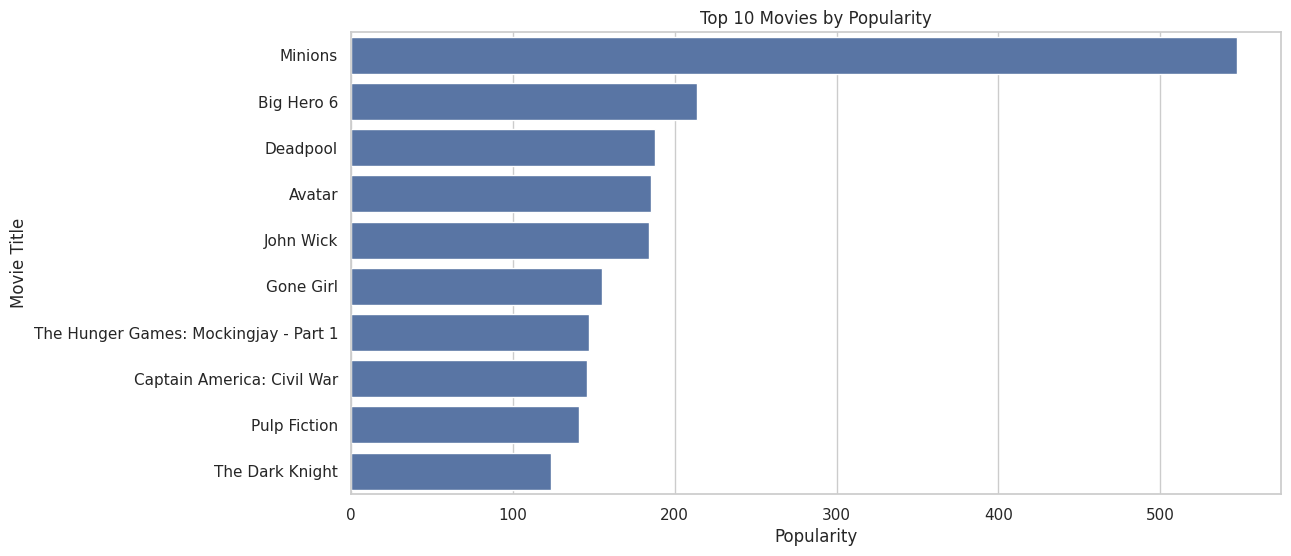

,title,popularity,vote_average,vote_count
8626,Minions,547.488298,6.4,4729.0
8415,Big Hero 6,213.849907,7.8,6289.0
8495,Deadpool,187.860492,7.4,11444.0
7198,Avatar,185.070892,7.2,12114.0
8406,John Wick,183.870374,7.0,5499.0
8340,Gone Girl,154.801009,7.9,6023.0
8431,The Hunger Games: Mockingjay - Part 1,147.098006,6.6,5767.0
8496,Captain America: Civil War,145.882135,7.1,7462.0
266,Pulp Fiction,140.950236,8.3,8670.0
6726,The Dark Knight,123.167259,8.3,12269.0


In [18]:
top_popular = movies_small.sort_values("popularity", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_popular, x="popularity", y="title")
plt.title("Top 10 Movies by Popularity")
plt.xlabel("Popularity")
plt.ylabel("Movie Title")
plt.show()

display(top_popular[["title", "popularity", "vote_average", "vote_count"]])

#### ***5.2. Top 10 movies by vote average with enough votes***


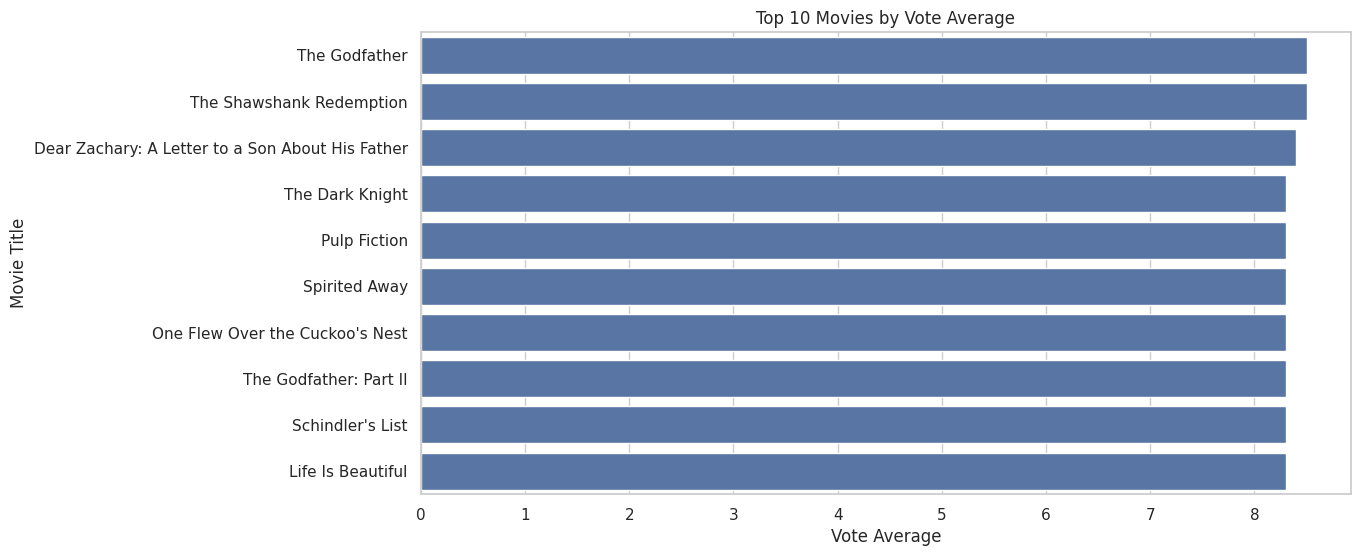

,title,vote_average,vote_count
692,The Godfather,8.5,6024.0
284,The Shawshank Redemption,8.5,8358.0
6931,Dear Zachary: A Letter to a Son About His Father,8.4,146.0
6726,The Dark Knight,8.3,12269.0
266,Pulp Fiction,8.3,8670.0
4166,Spirited Away,8.3,3968.0
945,One Flew Over the Cuckoo's Nest,8.3,3001.0
971,The Godfather: Part II,8.3,3418.0
472,Schindler's List,8.3,4436.0
1825,Life Is Beautiful,8.3,3643.0


In [19]:
top_vote_avg = movies_small[movies_small["vote_count"] >= 100].sort_values("vote_average", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_vote_avg, x="vote_average", y="title")
plt.title("Top 10 Movies by Vote Average")
plt.xlabel("Vote Average")
plt.ylabel("Movie Title")
plt.show()

display(top_vote_avg[["title", "vote_average", "vote_count"]])

#### ***5.3. Distribution of ratings***


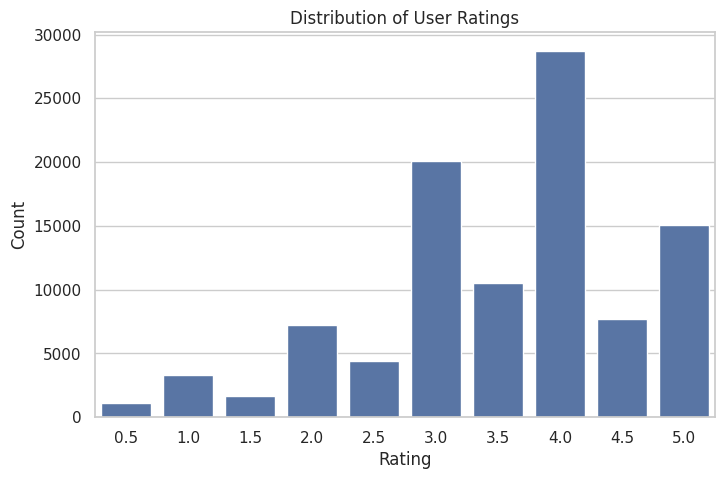

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ratings, x="rating")
plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#### ***5.4. Distribution of vote average***

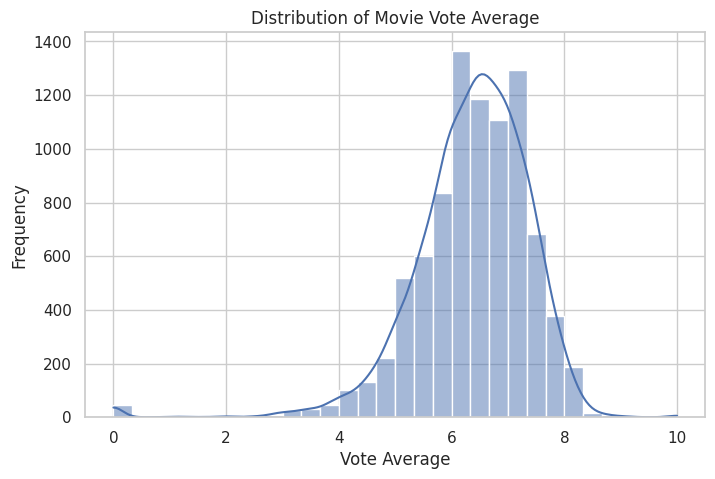

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(movies_small["vote_average"].dropna(), bins=30, kde=True)
plt.title("Distribution of Movie Vote Average")
plt.xlabel("Vote Average")
plt.ylabel("Frequency")
plt.show()

#### ***5.5. Number of movies by year***

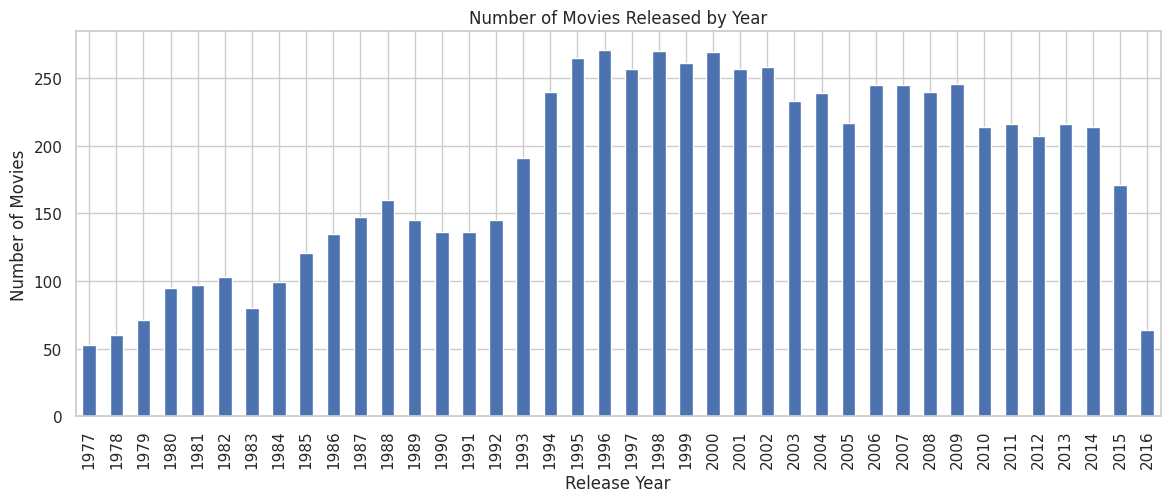

In [22]:
movies_by_year = movies_small["release_year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(14, 5))
movies_by_year.tail(40).plot(kind="bar")
plt.title("Number of Movies Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

#### ***5.6. Most common genres***

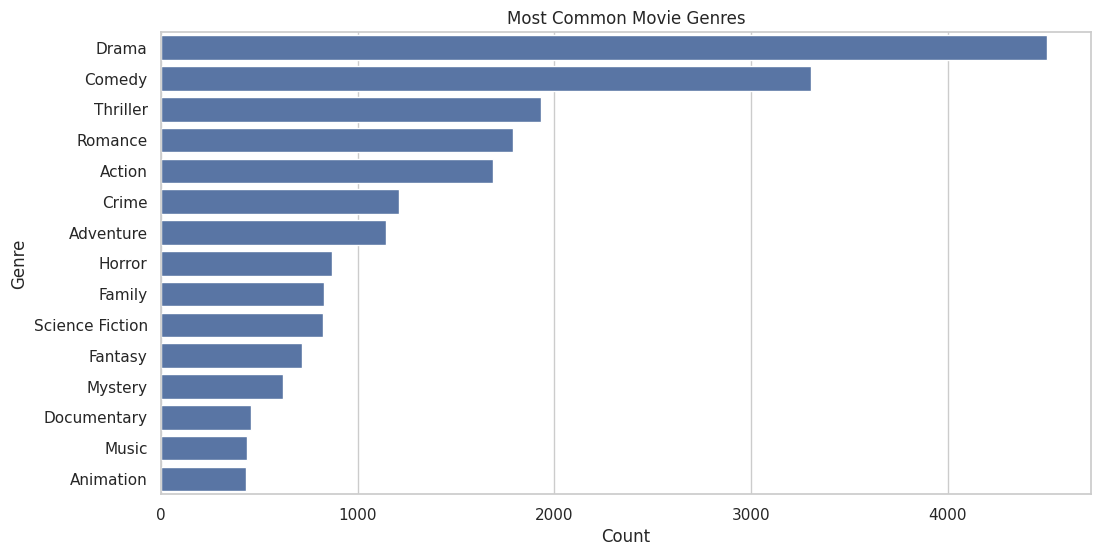

,Genre,Count
0,Drama,4503
1,Comedy,3303
2,Thriller,1934
3,Romance,1790
4,Action,1686
5,Crime,1209
6,Adventure,1147
7,Horror,869
8,Family,831
9,Science Fiction,824


In [23]:
all_genres = []
for genre_list in movies_small["genres_list"]:
    all_genres.extend(genre_list)

genre_counts = pd.DataFrame(Counter(all_genres).most_common(15), columns=["Genre", "Count"])

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_counts, x="Count", y="Genre")
plt.title("Most Common Movie Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

display(genre_counts)

#### ***5.7. Most active users***

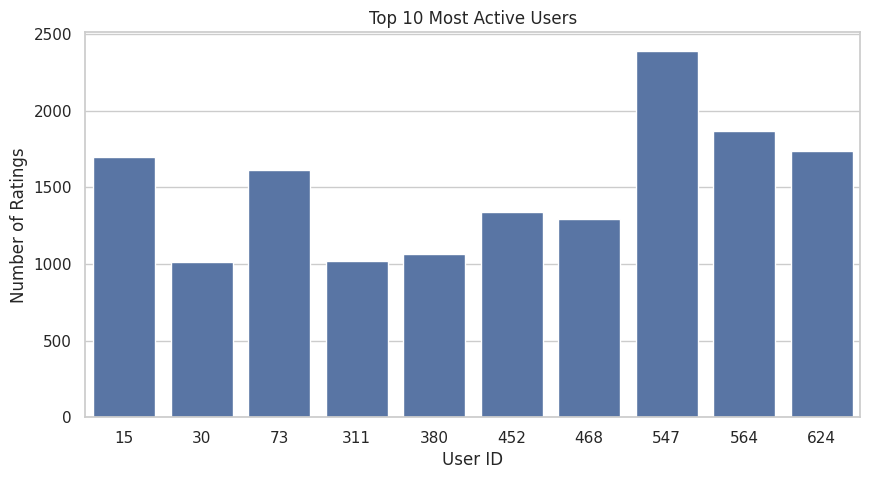

,userId,Number of Ratings
0,547,2391
1,564,1868
2,624,1735
3,15,1700
4,73,1610
5,452,1340
6,468,1291
7,380,1063
8,311,1019
9,30,1011


In [24]:
most_active_users = ratings["userId"].value_counts().head(10).reset_index()
most_active_users.columns = ["userId", "Number of Ratings"]

plt.figure(figsize=(10, 5))
sns.barplot(data=most_active_users, x="userId", y="Number of Ratings")
plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")
plt.show()

display(most_active_users)

#### ***5.8. Most rated movies***

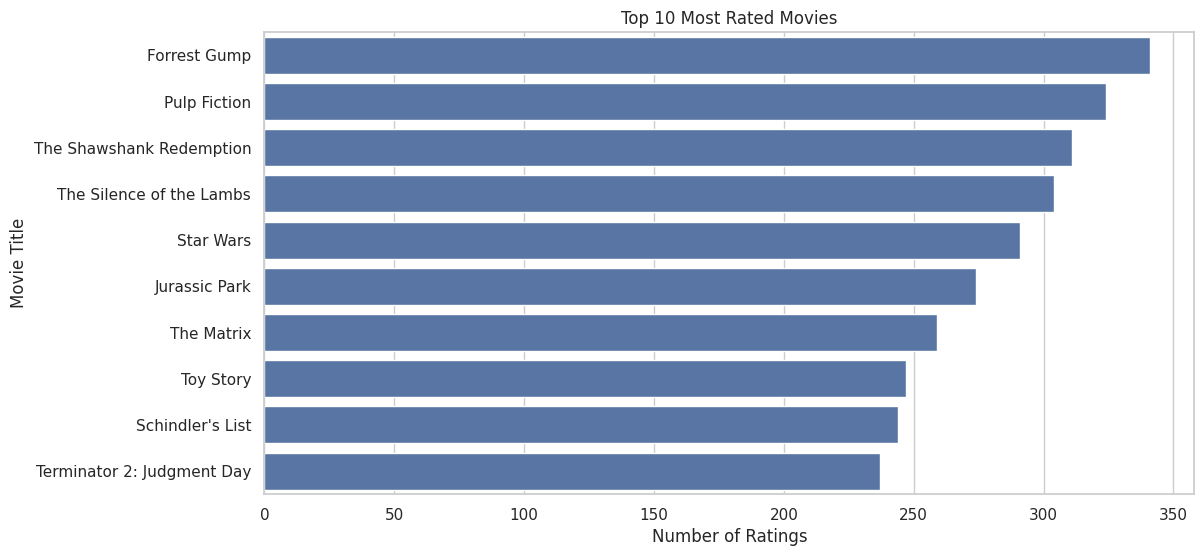

,Movie Title,Number of Ratings
0,Forrest Gump,341
1,Pulp Fiction,324
2,The Shawshank Redemption,311
3,The Silence of the Lambs,304
4,Star Wars,291
5,Jurassic Park,274
6,The Matrix,259
7,Toy Story,247
8,Schindler's List,244
9,Terminator 2: Judgment Day,237


In [25]:
rating_movie_titles = ratings.merge(movies_small[["movieId", "title"]], on="movieId", how="inner")
most_rated_movies = rating_movie_titles["title"].value_counts().head(10).reset_index()
most_rated_movies.columns = ["Movie Title", "Number of Ratings"]

plt.figure(figsize=(12, 6))
sns.barplot(data=most_rated_movies, x="Number of Ratings", y="Movie Title")
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()

display(most_rated_movies)

#### **5.9. Correlation analysis for useful numeric movie features**


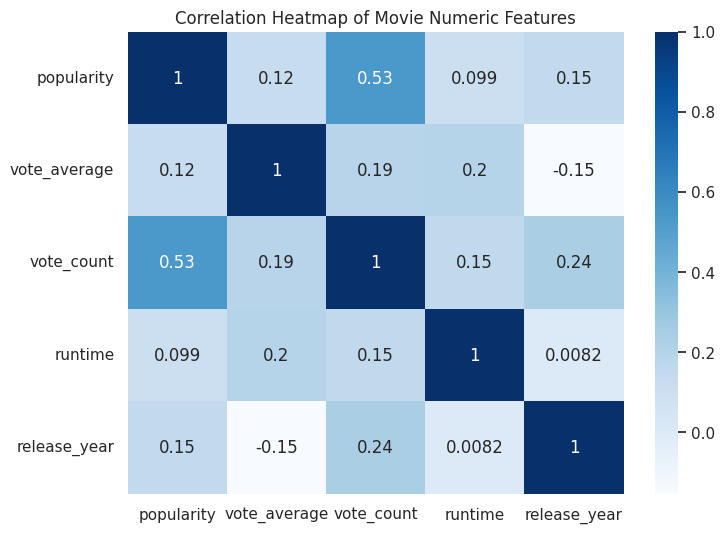

In [26]:
corr_cols = ["popularity", "vote_average", "vote_count", "runtime", "release_year"]
corr_data = movies_small[corr_cols].dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap of Movie Numeric Features")
plt.show()

## **6. Feature Engineering**



In [27]:
# Create clean text features for content-based recommendation
movies_small["clean_genres"] = movies_small["genres_list"].apply(clean_text_list)
movies_small["clean_keywords"] = movies_small["keywords_list"].apply(clean_text_list)
movies_small["clean_cast"] = movies_small["cast_list"].apply(clean_text_list)
movies_small["clean_director"] = movies_small["director"].apply(clean_single_text)

# Create soup feature
movies_small["soup"] = (
    movies_small["clean_genres"].apply(lambda x: " ".join(x)) + " " +
    movies_small["clean_keywords"].apply(lambda x: " ".join(x)) + " " +
    movies_small["clean_cast"].apply(lambda x: " ".join(x)) + " " +
    movies_small["clean_director"]
)

# Keep only important columns for recommendation
content_df = movies_small[
    [
        "movieId", "id", "title", "overview", "genres_list", "keywords_list",
        "cast_list", "director", "soup", "popularity", "vote_average",
        "vote_count", "release_year"
    ]
].copy()

content_df = content_df.dropna(subset=["title"]).reset_index(drop=True)

print("Content dataframe shape:", content_df.shape)
display(content_df.head())

Content dataframe shape: (8809, 13)


,movieId,id,title,overview,genres_list,keywords_list,cast_list,director,soup,popularity,vote_average,vote_count,release_year
0,1,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[Animation, Comedy, Family]","[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter,animation comedy family jealousy toy boy frien...,21.946943,7.7,5415.0,1995.0
1,2,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[Adventure, Fantasy, Family]","[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston,adventure fantasy family boardgame disappearan...,17.015539,6.9,2413.0,1995.0
2,3,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[Romance, Comedy]","[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch,romance comedy fishing bestfriend duringcredit...,11.712900,6.5,92.0,1995.0
3,4,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[Comedy, Drama, Romance]","[based on novel, interracial relationship, sin...","[Whitney Houston, Angela Bassett, Loretta Devine]",Forest Whitaker,comedy drama romance basedonnovel interracialr...,3.859495,6.1,34.0,1995.0
4,5,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,[Comedy],"[baby, midlife crisis, confidence, aging, daug...","[Steve Martin, Diane Keaton, Martin Short]",Charles Shyer,comedy baby midlifecrisis confidence aging dau...,8.387519,5.7,173.0,1995.0


In [28]:
# Helper function for safe movie title matching
def find_movie_index(movie_title, df=content_df):
    movie_title = str(movie_title).strip().lower()
    titles_lower = df["title"].str.lower()

    # Exact match first
    exact_matches = df[titles_lower == movie_title]
    if len(exact_matches) > 0:
        return exact_matches.index[0]

    # Partial match second
    partial_matches = df[titles_lower.str.contains(movie_title, na=False, regex=False)]
    if len(partial_matches) > 0:
        print(f"Exact title not found. Using closest match: {partial_matches.iloc[0]['title']}")
        return partial_matches.index[0]

    print(f"Movie '{movie_title}' not found in the dataset.")
    return None

## **7. Popularity-Based Recommendation**

Recommend movies based on popularity score.

In [29]:
def popularity_based_recommendation(top_n=10):
    result = content_df.sort_values("popularity", ascending=False).head(top_n)
    return result[["title", "popularity", "vote_average", "vote_count", "release_year"]]

popularity_based_recommendation(10)

,title,popularity,vote_average,vote_count,release_year
8626,Minions,547.488298,6.4,4729.0,2015.0
8415,Big Hero 6,213.849907,7.8,6289.0,2014.0
8495,Deadpool,187.860492,7.4,11444.0,2016.0
7198,Avatar,185.070892,7.2,12114.0,2009.0
8406,John Wick,183.870374,7.0,5499.0,2014.0
8340,Gone Girl,154.801009,7.9,6023.0,2014.0
8431,The Hunger Games: Mockingjay - Part 1,147.098006,6.6,5767.0,2014.0
8496,Captain America: Civil War,145.882135,7.1,7462.0,2016.0
266,Pulp Fiction,140.950236,8.3,8670.0,1994.0
6726,The Dark Knight,123.167259,8.3,12269.0,2008.0


## **8. Weighted Rating Recommendation**

Uses IMDb-style weighted rating formula to recommend movie


In [30]:
C = content_df["vote_average"].mean()
m = content_df["vote_count"].quantile(0.90)

def weighted_rating(row, m=m, C=C):
    v = row["vote_count"]
    R = row["vote_average"]
    if pd.isnull(v) or pd.isnull(R):
        return 0
    return (v / (v + m) * R) + (m / (v + m) * C)

content_df["weighted_rating"] = content_df.apply(weighted_rating, axis=1)

def weighted_rating_recommendation(top_n=10):
    qualified = content_df[content_df["vote_count"] >= m]
    result = qualified.sort_values("weighted_rating", ascending=False).head(top_n)
    return result[["title", "weighted_rating", "vote_average", "vote_count", "popularity"]]

weighted_rating_recommendation(10)

,title,weighted_rating,vote_average,vote_count,popularity
284,The Shawshank Redemption,8.251075,8.5,8358.0,51.645403
692,The Godfather,8.169546,8.5,6024.0,41.109264
6726,The Dark Knight,8.140370,8.3,12269.0,123.167259
2343,Fight Club,8.102003,8.3,9678.0,63.869599
266,Pulp Fiction,8.081580,8.3,8670.0,140.950236
321,Forrest Gump,7.981146,8.2,8147.0,48.307194
7346,Inception,7.973890,8.1,14075.0,29.108149
8258,Interstellar,7.944253,8.1,11187.0,32.213481
947,The Empire Strikes Back,7.914906,8.2,5998.0,19.470959
472,Schindler's List,7.914596,8.3,4436.0,41.725123


## **9. Content-Based Recommendation using TF-IDF + Cosine Similarity**

Recommends movies based on similarity between movie descriptions.

In [31]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=10000)
tfidf_matrix = tfidf_vectorizer.fit_transform(content_df["overview"].fillna(""))

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (8809, 10000)


In [32]:
def recommend_by_overview(movie_title, top_n=10):
    idx = find_movie_index(movie_title)
    if idx is None:
        return pd.DataFrame()

    # Calculate cosine similarity on demand to reduce memory usage
    similarity_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    similar_indices = similarity_scores.argsort()[::-1][1:top_n+1]

    result = content_df.iloc[similar_indices][["title", "overview", "vote_average", "release_year"]].copy()
    result["similarity_score"] = similarity_scores[similar_indices]
    return result.reset_index(drop=True)

recommend_by_overview("Toy Story", 10)

,title,overview,vote_average,release_year,similarity_score
0,Toy Story 3,"Woody, Buzz, and the rest of Andy's toys haven...",7.6,2010.0,0.525147
1,Toy Story 2,"Andy heads off to Cowboy Camp, leaving his toy...",7.3,1999.0,0.436888
2,The 40 Year Old Virgin,Andy Stitzer has a pleasant life with a nice a...,6.2,2005.0,0.322159
3,Rivers and Tides,"Portrait of Andy Goldsworthy, an artist whose ...",7.3,2001.0,0.208013
4,Factory Girl,"In the mid-1960s, wealthy debutant Edie Sedgwi...",6.2,2006.0,0.190342
5,Man on the Moon,A film about the life and career of the eccent...,6.9,1999.0,0.189214
6,Rebel Without a Cause,"After moving to a new town, troublemaking teen...",7.6,1955.0,0.183188
7,For Your Consideration,Three actors learn that their respective perfo...,5.9,2006.0,0.171475
8,Condorman,Comic artist and writer Woody performs a simpl...,5.6,1981.0,0.170383
9,Malice,A tale about a happily married couple who woul...,5.9,1993.0,0.162106


## **10. Content-Based Recommendation using CountVectorizer + Cosine Similarity**

Recommend movies using metadata like genres, keywords, cast, and director.

In [33]:
# CountVectorizer on combined metadata soup
count_vectorizer = CountVectorizer(stop_words="english", max_features=10000)
count_matrix = count_vectorizer.fit_transform(content_df["soup"].fillna(""))

print("CountVectorizer matrix shape:", count_matrix.shape)

CountVectorizer matrix shape: (8809, 10000)


In [34]:
def recommend_by_metadata(movie_title, top_n=10):
    idx = find_movie_index(movie_title)
    if idx is None:
        return pd.DataFrame()

    # Calculate cosine similarity on demand to reduce memory usage
    similarity_scores = cosine_similarity(count_matrix[idx], count_matrix).flatten()
    similar_indices = similarity_scores.argsort()[::-1][1:top_n+1]

    result = content_df.iloc[similar_indices][["title", "genres_list", "keywords_list", "cast_list", "director", "vote_average"]].copy()
    result["similarity_score"] = similarity_scores[similar_indices]
    return result.reset_index(drop=True)

recommend_by_metadata("Toy Story", 10)

,title,genres_list,keywords_list,cast_list,director,vote_average,similarity_score
0,Toy Story 3,"[Animation, Family, Comedy]","[hostage, college, toy, barbie, animation, esc...","[Tom Hanks, Tim Allen, Ned Beatty]",Lee Unkrich,7.6,0.458831
1,Toy Story 2,"[Animation, Comedy, Family]","[museum, prosecution, identity crisis, airplan...","[Tom Hanks, Tim Allen, Joan Cusack]",John Lasseter,7.3,0.447214
2,Toy Story of Terror!,"[Animation, Comedy, Family]","[halloween, toys, short]","[Tom Hanks, Tim Allen, Kristen Schaal]",Angus MacLane,7.3,0.441942
3,"Bon Voyage, Charlie Brown (and Don't Come Back!)","[Animation, Comedy, Family]",[peanuts],"[Arrin Skelley, Laura Planting, Casey Carlson]",Phil Roman,6.2,0.433013
4,Creature Comforts,"[Animation, Comedy, Family]",[animation],[],Nick Park,7.3,0.377964
5,Is It College Yet?,"[Animation, Comedy]",[],"[Tracy Grandstaff, Wendy Hoopes]",Karen Disher,7.4,0.353553
6,Hey Arnold! The Movie,"[Animation, Family]",[],"[Spencer Klein, Francesca Smith, Jamil Walker ...",Tuck Tucker,5.6,0.353553
7,Is It Fall Yet?,"[Animation, Comedy]",[],"[Tracy Grandstaff, Wendy Hoopes]",Karen Disher,7.5,0.353553
8,Spirit: Stallion of the Cimarron,"[Western, Animation, Adventure, Comedy, Family]","[human being, freedom, mustang, rivalry, wildl...","[Matt Damon, James Cromwell, Daniel Studi]",Kelly Asbury,7.4,0.312500
9,Stuart Little 2,"[Family, Adventure, Animation, Comedy]","[mouse, falcon, bird, friendship, family]","[Michael J. Fox, Geena Davis, Hugh Laurie]",Rob Minkoff,5.4,0.312500


## **11. Collaborative Filtering using KNN**

Recommend movies based on similar user-rating behavior.

In [35]:
# Merge ratings with movie titles
ratings_with_titles = ratings.merge(content_df[["movieId", "title"]], on="movieId", how="inner")

# Create movie-user rating matrix
movie_user_matrix = ratings_with_titles.pivot_table(
    index="title",
    columns="userId",
    values="rating"
).fillna(0)

# Convert to sparse matrix
movie_user_sparse = csr_matrix(movie_user_matrix.values)

# Train KNN model
knn_model = NearestNeighbors(metric="cosine", algorithm="brute")
knn_model.fit(movie_user_sparse)

print("Movie-user matrix shape:", movie_user_matrix.shape)
print("KNN collaborative filtering model trained successfully.")

Movie-user matrix shape: (8754, 671)
KNN collaborative filtering model trained successfully.


In [36]:
def recommend_by_knn(movie_title, top_n=10):
    movie_title_lower = str(movie_title).strip().lower()
    movie_titles_lower = pd.Series(movie_user_matrix.index).str.lower()

    exact_matches = np.where(movie_titles_lower == movie_title_lower)[0]
    if len(exact_matches) == 0:
        partial_matches = np.where(movie_titles_lower.str.contains(movie_title_lower, regex=False, na=False))[0]
        if len(partial_matches) == 0:
            print(f"Movie '{movie_title}' not found in rating matrix.")
            return pd.DataFrame()
        movie_idx = partial_matches[0]
        print(f"Exact title not found. Using closest match: {movie_user_matrix.index[movie_idx]}")
    else:
        movie_idx = exact_matches[0]

    distances, indices = knn_model.kneighbors(
        movie_user_matrix.iloc[movie_idx, :].values.reshape(1, -1),
        n_neighbors=top_n + 1
    )

    recommendations = []
    for i in range(1, len(indices.flatten())):
        rec_title = movie_user_matrix.index[indices.flatten()[i]]
        similarity = 1 - distances.flatten()[i]
        recommendations.append((rec_title, similarity))

    return pd.DataFrame(recommendations, columns=["title", "similarity_score"])

recommend_by_knn("Toy Story", 10)

,title,similarity_score
0,Toy Story 2,0.594710
1,Star Wars,0.576188
2,Forrest Gump,0.564534
3,Independence Day,0.562946
4,Groundhog Day,0.548023
5,Back to the Future,0.536700
6,Jurassic Park,0.535197
7,Shrek,0.532685
8,Return of the Jedi,0.529334
9,Pulp Fiction,0.526862


## **12. Matrix Factorization using SVD**


In [37]:
svd_model = None
svd_rmse = None
svd_mae = None

if SURPRISE_AVAILABLE:
    reader = Reader(rating_scale=(0.5, 5.0))
    surprise_data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)

    trainset, testset = surprise_train_test_split(
        surprise_data,
        test_size=0.2,
        random_state=42
    )

    svd_model = SVD(random_state=42)
    svd_model.fit(trainset)

    svd_predictions = svd_model.test(testset)
    svd_rmse = accuracy.rmse(svd_predictions, verbose=True)
    svd_mae = accuracy.mae(svd_predictions, verbose=True)

    print("SVD model trained successfully.")
else:
    print("Surprise is not available, so SVD model is skipped.")

RMSE: 0.9024
MAE:  0.6954
SVD model trained successfully.


In [48]:
def recommend_by_svd(user_id, top_n=10):
    if svd_model is None:
        print("SVD model is not available.")
        return pd.DataFrame()

    user_id = int(user_id)
    all_movie_ids = set(content_df["movieId"].unique())
    rated_movie_ids = set(ratings[ratings["userId"] == user_id]["movieId"].unique())
    unrated_movie_ids = list(all_movie_ids - rated_movie_ids)

    predictions = []
    for movie_id in unrated_movie_ids:
        pred = svd_model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    pred_df = pd.DataFrame(predictions, columns=["movieId", "predicted_rating"])

    result = pred_df.merge(content_df[["movieId", "title", "genres_list", "vote_average"]], on="movieId", how="left")
    return result[["title", "predicted_rating", "genres_list", "vote_average"]]

recommend_by_svd(user_id=1, top_n=10)

,title,predicted_rating,genres_list,vote_average
0,The African Queen,3.888561,"[Adventure, War, Romance]",7.4
1,The Godfather,3.869988,"[Drama, Crime]",8.5
2,Das Boot,3.754281,"[Action, Drama, History, War, Adventure]",7.9
3,Stand by Me,3.735564,"[Crime, Drama]",7.8
4,The Shawshank Redemption,3.718731,"[Drama, Crime]",8.5
5,Happiness,3.717193,"[Comedy, Drama]",7.4
6,The Dark Knight,3.680959,"[Drama, Action, Crime, Thriller]",8.3
7,Lawrence of Arabia,3.680950,"[Adventure, Drama, History, War]",7.8
8,Reservoir Dogs,3.673413,"[Crime, Thriller]",8.1
9,Nashville,3.672566,"[Drama, Music]",7.2


## **13. Hybrid Recommendation System**

The hybrid system combines:
- content-based metadata similarity,
- and SVD predicted user rating.


In [49]:
def hybrid_recommendation(user_id, movie_title, top_n=10):
    if svd_model is None:
        print("SVD model is not available. Returning metadata-based recommendations only.")
        return recommend_by_metadata(movie_title, top_n)

    idx = find_movie_index(movie_title)
    if idx is None:
        return pd.DataFrame()

    # First find similar movies using content-based metadata similarity
    similarity_scores = cosine_similarity(count_matrix[idx], count_matrix).flatten()
    similar_indices = similarity_scores.argsort()[::-1][1:50]  # Take top 50 similar movies

    candidate_movies = content_df.iloc[similar_indices][["movieId", "title", "genres_list", "vote_average"]].copy()
    candidate_movies["content_similarity"] = similarity_scores[similar_indices]

    # Predict rating for candidate movies using SVD
    candidate_movies["predicted_rating"] = candidate_movies["movieId"].apply(
        lambda movie_id: svd_model.predict(int(user_id), int(movie_id)).est
    )

    # Hybrid score: combine predicted rating and content similarity
    candidate_movies["hybrid_score"] = (
        0.7 * candidate_movies["predicted_rating"] +
        0.3 * candidate_movies["content_similarity"] * 5
    )

    result = candidate_movies.sort_values("hybrid_score", ascending=False).head(top_n)
    return result[["title", "genres_list", "vote_average", "content_similarity", "predicted_rating", "hybrid_score"]]

hybrid_recommendation(user_id=1, movie_title="Toy Story", top_n=10)

,title,genres_list,vote_average,content_similarity,predicted_rating,hybrid_score
7328,Toy Story 3,"[Animation, Family, Comedy]",7.6,0.458831,3.304394,3.001323
5131,"Bon Voyage, Charlie Brown (and Don't Come Back!)","[Animation, Comedy, Family]",6.2,0.433013,3.171656,2.869678
2699,Creature Comforts,"[Animation, Comedy, Family]",7.3,0.377964,3.286381,2.867414
2471,Toy Story 2,"[Animation, Comedy, Family]",7.3,0.447214,3.128491,2.860764
8168,Toy Story of Terror!,"[Animation, Comedy, Family]",7.3,0.441942,3.119731,2.846725
7032,Up,"[Animation, Comedy, Family, Adventure]",7.8,0.277350,3.424664,2.813290
3755,"Monsters, Inc.","[Animation, Comedy, Family]",7.5,0.258199,3.404447,2.770411
2212,Big,"[Fantasy, Drama, Comedy, Romance, Family]",6.9,0.258199,3.266892,2.674123
8610,Inside Out,"[Drama, Comedy, Animation, Family]",7.9,0.272772,3.209813,2.656027
528,Pinocchio,"[Animation, Family]",6.9,0.279508,3.103769,2.591901


## **15. Model Evaluation**

For recommendation systems, evaluation depends on the type of recommender:

#### Content-Based Models
#### KNN Collaborative Filtering


In [51]:
# Sample recommendations for content-based models
sample_movies = ["Toy Story", "Jumanji", "The Dark Knight"]

for movie in sample_movies:
    print("=" * 80)
    print(f"TF-IDF Overview Recommendations for: {movie}")
    display(recommend_by_overview(movie, 5))

    print(f"Metadata Recommendations for: {movie}")
    display(recommend_by_metadata(movie, 5))

TF-IDF Overview Recommendations for: Toy Story


,title,overview,vote_average,release_year,similarity_score
0,Toy Story 3,"Woody, Buzz, and the rest of Andy's toys haven...",7.6,2010.0,0.525147
1,Toy Story 2,"Andy heads off to Cowboy Camp, leaving his toy...",7.3,1999.0,0.436888
2,The 40 Year Old Virgin,Andy Stitzer has a pleasant life with a nice a...,6.2,2005.0,0.322159
3,Rivers and Tides,"Portrait of Andy Goldsworthy, an artist whose ...",7.3,2001.0,0.208013
4,Factory Girl,"In the mid-1960s, wealthy debutant Edie Sedgwi...",6.2,2006.0,0.190342


Metadata Recommendations for: Toy Story


,title,genres_list,keywords_list,cast_list,director,vote_average,similarity_score
0,Toy Story 3,"[Animation, Family, Comedy]","[hostage, college, toy, barbie, animation, esc...","[Tom Hanks, Tim Allen, Ned Beatty]",Lee Unkrich,7.6,0.458831
1,Toy Story 2,"[Animation, Comedy, Family]","[museum, prosecution, identity crisis, airplan...","[Tom Hanks, Tim Allen, Joan Cusack]",John Lasseter,7.3,0.447214
2,Toy Story of Terror!,"[Animation, Comedy, Family]","[halloween, toys, short]","[Tom Hanks, Tim Allen, Kristen Schaal]",Angus MacLane,7.3,0.441942
3,"Bon Voyage, Charlie Brown (and Don't Come Back!)","[Animation, Comedy, Family]",[peanuts],"[Arrin Skelley, Laura Planting, Casey Carlson]",Phil Roman,6.2,0.433013
4,Creature Comforts,"[Animation, Comedy, Family]",[animation],[],Nick Park,7.3,0.377964


TF-IDF Overview Recommendations for: Jumanji


...

,title,genres_list,keywords_list,cast_list,director,vote_average,similarity_score
0,Return to Oz,"[Adventure, Family, Fantasy]",[wizard of oz],"[Fairuza Balk, Nicol Williamson, Jean Marsh]",Walter Murch,6.6,0.416025
1,Kirikou and the Sorceress,"[Fantasy, Adventure, Animation, Family]",[],"[Doudou Gueye Thiaw, Maimouna N'Diaye, Awa Sen...",Michel Ocelot,7.2,0.416025
2,Arthur and the Invisibles,"[Adventure, Fantasy, Animation, Family]","[grandfather grandson relationship, wretch, tr...","[Freddie Highmore, Mia Farrow, Ron Crawford]",Luc Besson,6.0,0.358057
3,Jason and the Argonauts,"[Adventure, Family, Fantasy]","[hero, menace, bravery, adventure, vlies]","[Todd Armstrong, Nancy Kovack, Gary Raymond]",Don Chaffey,7.1,0.350823
4,Little Nemo: Adventures In Slumberland,"[Adventure, Animation, Family, Fantasy]",[],"[Gabriel Damon, Mickey Rooney, Rene Auberjonois]",Masami Hata,7.1,0.339683


TF-IDF Overview Recommendations for: The Dark Knight


,title,overview,vote_average,release_year,similarity_score
0,The Dark Knight Rises,Following the death of District Attorney Harve...,7.6,2012.0,0.330340
1,Batman Returns,"Having defeated the Joker, Batman now faces th...",6.6,1992.0,0.284115
2,Batman Forever,The Dark Knight of Gotham City confronts a das...,5.2,1995.0,0.260626
3,Batman: Under the Red Hood,Batman faces his ultimate challenge as the mys...,7.6,2010.0,0.258192
4,"Batman: The Dark Knight Returns, Part 2",Batman has stopped the reign of terror that Th...,7.9,2013.0,0.231009


Metadata Recommendations for: The Dark Knight


,title,genres_list,keywords_list,cast_list,director,vote_average,similarity_score
0,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan,7.6,0.592593
1,Batman Begins,"[Action, Crime, Drama]","[himalaya, martial arts, dc comics, crime figh...","[Christian Bale, Michael Caine, Liam Neeson]",Christopher Nolan,7.5,0.528079
2,Batman: Under the Red Hood,"[Action, Animation]","[martial arts, dc comics, vigilante, joker, su...","[Bruce Greenwood, Jensen Ackles, Neil Patrick ...",Brandon Vietti,7.6,0.384900
3,Harsh Times,"[Crime, Drama, Thriller, Action]","[watching a movie, playing pool, vinegar]","[Christian Bale, Freddy Rodríguez, Eva Longoria]",David Ayer,6.3,0.363696
4,Batman & Robin,"[Action, Crime, Fantasy]","[double life, dc comics, dual identity, crime ...","[George Clooney, Chris O'Donnell, Arnold Schwa...",Joel Schumacher,4.2,0.336788


In [52]:
# Sample KNN recommendation
print("KNN Collaborative Filtering Recommendations:")
display(recommend_by_knn("Toy Story", 10))

KNN Collaborative Filtering Recommendations:


,title,similarity_score
0,Toy Story 2,0.594710
1,Star Wars,0.576188
2,Forrest Gump,0.564534
3,Independence Day,0.562946
4,Groundhog Day,0.548023
5,Back to the Future,0.536700
6,Jurassic Park,0.535197
7,Shrek,0.532685
8,Return of the Jedi,0.529334
9,Pulp Fiction,0.526862


In [53]:
# Performance comparison table
performance_results = [
    {
        "Model": "Popularity-Based",
        "Type": "Ranking",
        "Evaluation": "Top popular movies",
        "RMSE": "N/A",
        "MAE": "N/A"
    },
    {
        "Model": "Weighted Rating",
        "Type": "Ranking",
        "Evaluation": "IMDb-style weighted score",
        "RMSE": "N/A",
        "MAE": "N/A"
    },
    {
        "Model": "TF-IDF Content-Based",
        "Type": "Content-Based",
        "Evaluation": "Qualitative similarity",
        "RMSE": "N/A",
        "MAE": "N/A"
    },
    {
        "Model": "Metadata Content-Based",
        "Type": "Content-Based",
        "Evaluation": "Qualitative similarity",
        "RMSE": "N/A",
        "MAE": "N/A"
    },
    {
        "Model": "KNN Collaborative Filtering",
        "Type": "Collaborative Filtering",
        "Evaluation": "Similar user-rating behavior",
        "RMSE": "N/A",
        "MAE": "N/A"
    },
    {
        "Model": "SVD Matrix Factorization",
        "Type": "Matrix Factorization",
        "Evaluation": "RMSE and MAE",
        "RMSE": svd_rmse if svd_rmse is not None else "N/A",
        "MAE": svd_mae if svd_mae is not None else "N/A"
    },
    {
        "Model": "Hybrid Recommendation",
        "Type": "Hybrid",
        "Evaluation": "Content similarity + predicted rating",
        "RMSE": "N/A",
        "MAE": "N/A"
    }
]

performance_df = pd.DataFrame(performance_results)
display(performance_df)

,Model,Type,Evaluation,RMSE,MAE
0,Popularity-Based,Ranking,Top popular movies,N/A,N/A
1,Weighted Rating,Ranking,IMDb-style weighted score,N/A,N/A
2,TF-IDF Content-Based,Content-Based,Qualitative similarity,N/A,N/A
3,Metadata Content-Based,Content-Based,Qualitative similarity,N/A,N/A
4,KNN Collaborative Filtering,Collaborative Filtering,Similar user-rating behavior,N/A,N/A
5,SVD Matrix Factorization,Matrix Factorization,RMSE and MAE,0.902377,0.695381
6,Hybrid Recommendation,Hybrid,Content similarity + predicted rating,N/A,N/A


## **16. Testing the Recommendation System**

All recommendation functions using sample inputs.

In [54]:
print("1. Popularity-Based Recommendation")
display(popularity_based_recommendation(10))

print("2. Weighted Rating Recommendation")
display(weighted_rating_recommendation(10))

print("3. TF-IDF Overview Recommendation")
display(recommend_by_overview("Toy Story", 10))

print("4. Metadata-Based Recommendation")
display(recommend_by_metadata("Toy Story", 10))

print("5. KNN Collaborative Filtering Recommendation")
display(recommend_by_knn("Toy Story", 10))

print("6. SVD Recommendation")
display(recommend_by_svd(user_id=1, top_n=10))

print("8. Hybrid Recommendation")
display(hybrid_recommendation(user_id=1, movie_title="Toy Story", top_n=10))

1. Popularity-Based Recommendation


,title,popularity,vote_average,vote_count,release_year
8626,Minions,547.488298,6.4,4729.0,2015.0
8415,Big Hero 6,213.849907,7.8,6289.0,2014.0
8495,Deadpool,187.860492,7.4,11444.0,2016.0
7198,Avatar,185.070892,7.2,12114.0,2009.0
8406,John Wick,183.870374,7.0,5499.0,2014.0
8340,Gone Girl,154.801009,7.9,6023.0,2014.0
8431,The Hunger Games: Mockingjay - Part 1,147.098006,6.6,5767.0,2014.0
8496,Captain America: Civil War,145.882135,7.1,7462.0,2016.0
266,Pulp Fiction,140.950236,8.3,8670.0,1994.0
6726,The Dark Knight,123.167259,8.3,12269.0,2008.0


2. Weighted Rating Recommendation


,title,weighted_rating,vote_average,vote_count,popularity
284,The Shawshank Redemption,8.251075,8.5,8358.0,51.645403
692,The Godfather,8.169546,8.5,6024.0,41.109264
6726,The Dark Knight,8.140370,8.3,12269.0,123.167259
2343,Fight Club,8.102003,8.3,9678.0,63.869599
266,Pulp Fiction,8.081580,8.3,8670.0,140.950236
321,Forrest Gump,7.981146,8.2,8147.0,48.307194
7346,Inception,7.973890,8.1,14075.0,29.108149
8258,Interstellar,7.944253,8.1,11187.0,32.213481
947,The Empire Strikes Back,7.914906,8.2,5998.0,19.470959
472,Schindler's List,7.914596,8.3,4436.0,41.725123


3. TF-IDF Overview Recommendation


...

,title,similarity_score
0,Toy Story 2,0.594710
1,Star Wars,0.576188
2,Forrest Gump,0.564534
3,Independence Day,0.562946
4,Groundhog Day,0.548023
5,Back to the Future,0.536700
6,Jurassic Park,0.535197
7,Shrek,0.532685
8,Return of the Jedi,0.529334
9,Pulp Fiction,0.526862


6. SVD Recommendation


,title,predicted_rating,genres_list,vote_average
0,The African Queen,3.888561,"[Adventure, War, Romance]",7.4
1,The Godfather,3.869988,"[Drama, Crime]",8.5
2,Das Boot,3.754281,"[Action, Drama, History, War, Adventure]",7.9
3,Stand by Me,3.735564,"[Crime, Drama]",7.8
4,The Shawshank Redemption,3.718731,"[Drama, Crime]",8.5
5,Happiness,3.717193,"[Comedy, Drama]",7.4
6,The Dark Knight,3.680959,"[Drama, Action, Crime, Thriller]",8.3
7,Lawrence of Arabia,3.680950,"[Adventure, Drama, History, War]",7.8
8,Reservoir Dogs,3.673413,"[Crime, Thriller]",8.1
9,Nashville,3.672566,"[Drama, Music]",7.2


8. Hybrid Recommendation


,title,genres_list,vote_average,content_similarity,predicted_rating,hybrid_score
7328,Toy Story 3,"[Animation, Family, Comedy]",7.6,0.458831,3.304394,3.001323
5131,"Bon Voyage, Charlie Brown (and Don't Come Back!)","[Animation, Comedy, Family]",6.2,0.433013,3.171656,2.869678
2699,Creature Comforts,"[Animation, Comedy, Family]",7.3,0.377964,3.286381,2.867414
2471,Toy Story 2,"[Animation, Comedy, Family]",7.3,0.447214,3.128491,2.860764
8168,Toy Story of Terror!,"[Animation, Comedy, Family]",7.3,0.441942,3.119731,2.846725
7032,Up,"[Animation, Comedy, Family, Adventure]",7.8,0.277350,3.424664,2.813290
3755,"Monsters, Inc.","[Animation, Comedy, Family]",7.5,0.258199,3.404447,2.770411
2212,Big,"[Fantasy, Drama, Comedy, Romance, Family]",6.9,0.258199,3.266892,2.674123
8610,Inside Out,"[Drama, Comedy, Animation, Family]",7.9,0.272772,3.209813,2.656027
528,Pinocchio,"[Animation, Family]",6.9,0.279508,3.103769,2.591901


## **17. Save Models and Files**



In [55]:
SAVE_DIR = "saved_recommender_files"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save vectorizers
joblib.dump(tfidf_vectorizer, os.path.join(SAVE_DIR, "tfidf_vectorizer.pkl"))
joblib.dump(count_vectorizer, os.path.join(SAVE_DIR, "count_vectorizer.pkl"))

# Save sparse matrices
sparse.save_npz(os.path.join(SAVE_DIR, "tfidf_matrix.npz"), tfidf_matrix)
sparse.save_npz(os.path.join(SAVE_DIR, "count_matrix.npz"), count_matrix)
sparse.save_npz(os.path.join(SAVE_DIR, "movie_user_sparse_matrix.npz"), movie_user_sparse)

# Save KNN model
joblib.dump(knn_model, os.path.join(SAVE_DIR, "knn_collaborative_model.pkl"))

# Save Surprise models if available
if svd_model is not None:
    with open(os.path.join(SAVE_DIR, "svd_model.pkl"), "wb") as f:
        pickle.dump(svd_model, f)

if nmf_model is not None:
    with open(os.path.join(SAVE_DIR, "nmf_model.pkl"), "wb") as f:
        pickle.dump(nmf_model, f)

# Save cleaned dataframes
content_df.to_csv(os.path.join(SAVE_DIR, "cleaned_movies.csv"), index=False)
performance_df.to_csv(os.path.join(SAVE_DIR, "performance_comparison.csv"), index=False)

print("Models and files saved successfully in:", SAVE_DIR)
print(os.listdir(SAVE_DIR))

Models and files saved successfully in: saved_recommender_files
['nmf_model.pkl', 'tfidf_vectorizer.pkl', 'svd_model.pkl', 'cleaned_movies.csv', 'count_vectorizer.pkl', 'tfidf_matrix.npz', 'performance_comparison.csv', 'knn_collaborative_model.pkl', 'movie_user_sparse_matrix.npz', 'count_matrix.npz']
